# Section 1. Install deps

In [1]:
!pip install pandas numpy gdown

# Section 2. Data access

In [2]:
import pandas as pd
import gdown

file_id = "1Nv079uUCOAsO-cVQQ_UflV5xy9nkgZ6O"

url = f"https://drive.google.com/uc?id={file_id}"

output = "processed_v2.csv"
gdown.download(url, output, quiet=False)

df = pd.read_csv(output)
df.head(5)

Downloading...
From: https://drive.google.com/uc?id=1Nv079uUCOAsO-cVQQ_UflV5xy9nkgZ6O
To: /content/processed_v2.csv
100%|██████████| 4.21M/4.21M [00:00<00:00, 39.7MB/s]


,title,text,category_id
0,Івано-Франківський драмтеатр знайшов архівні д...,{'clean': 'на пресконференції гендиректор-худо...,0
1,Премія Олеся Гончара оголосила номінантів,{'clean': 'Держмистецтв. Цьогоріч на здобуття ...,0
2,Біографічний фільм «Я граю Роккі» вийде у лист...,{'clean': ' The Hollywood Reporter. Стрічка ві...,0
3,Netflix підписав угоду на трансляцію фільмів S...,"{'clean': 'Deadline. Зазначається, що найважли...",0
4,На Венеційській бієнале Україну представить ск...,{'clean': 'розповіли учасники Венеційської біє...,0


# Section 3. Load split

In [3]:
import ast

def load_ids(file_id, filename):
    gdown.download(f"https://drive.google.com/uc?id={file_id}", filename, quiet=False)
    with open(filename, "r") as f:
        ids = [int(line.strip()) for line in f]

    return ids

train_ids = load_ids("1t9vBXkyuP3a_Mkp52E2xb4Z3fm-ee78k", "train.txt")
val_ids = load_ids("1tkKDJxxeXaiQIUzYb9b0T0CARwG3SnSw", "val.txt")
test_ids = load_ids("1e1P2W-ktB5NlKiJkKUr9rJqnS5SCVH6A", "test.txt")

X_train = df.loc[train_ids, "text"].apply(lambda x: ast.literal_eval(x)["clean"])
X_val = df.loc[val_ids, "text"].apply(lambda x: ast.literal_eval(x)["clean"])
X_test = df.loc[test_ids, "text"].apply(lambda x: ast.literal_eval(x)["clean"])

y_train = df.loc[train_ids, "category_id"]
y_val = df.loc[val_ids, "category_id"]
y_test = df.loc[test_ids, "category_id"]



Downloading...
From: https://drive.google.com/uc?id=1t9vBXkyuP3a_Mkp52E2xb4Z3fm-ee78k
To: /content/train.txt
100%|██████████| 2.24k/2.24k [00:00<00:00, 5.97MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tkKDJxxeXaiQIUzYb9b0T0CARwG3SnSw
To: /content/val.txt
100%|██████████| 472/472 [00:00<00:00, 1.43MB/s]
Downloading...
From: https://drive.google.com/uc?id=1e1P2W-ktB5NlKiJkKUr9rJqnS5SCVH6A
To: /content/test.txt
100%|██████████| 491/491 [00:00<00:00, 1.43MB/s]


# Section 4. Reproduce Lab6 baseline

In [4]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

def run_logreg_baseline(X_train, X_test, y_train, y_test):

    ukr_stopwords = [
        "про", "що", "та", "для", "це", "як", "але", "або", "він", "ми",
        "щоб", "році", "року", "бути", "стати", "щодо", "його", "які",
        "на", "2025", "сказав", "який", "від", "також", "лютого", "про це",
        "місце", "серед", "те", "2026", "зокрема" "пам", "рік",
    ]

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1,2),
            max_features=30000,
            min_df=3,
            stop_words=ukr_stopwords
        )),
        ("clf", LogisticRegression(max_iter=500, n_jobs=-1))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    print("Accuracy:", acc)
    print("Macro F1:", f1)
    print("Classification report:\n", classification_report(y_test, y_pred))
    print("\n")

    errors_df = pd.DataFrame({
        "text": X_test,
        "gold_label": y_test,
        "predicted_label": y_pred
    })
    errors_df = errors_df[errors_df["gold_label"] != errors_df["predicted_label"]]
    errors_df = errors_df.reset_index().rename(columns={"index": "text_id"})

    return pipeline, y_pred, acc, f1, errors_df


In [5]:
import numpy as np


pipeline_lr, y_pred_lr, acc_lr, f1_lr, errors_df = run_logreg_baseline(
    X_train, X_test,
    y_train, y_test,
)

vectorizer = pipeline_lr.named_steps["tfidf"]
clf = pipeline_lr.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()
classes = clf.classes_

for i, class_label in enumerate(classes):
    print(f"\n-------- Клас: {class_label} --------")

    coefs = clf.coef_[i]
    top_positive_idx = np.argsort(coefs)[-10:][::-1]
    print("\nТоп-10 позитивних фіч:")
    for idx in top_positive_idx:
        print(f"{feature_names[idx]}: {coefs[idx]:.4f}")

    top_negative_idx = np.argsort(coefs)[:10]
    print("\nТоп-10 негативних фіч:")
    for idx in top_negative_idx:
        print(f"{feature_names[idx]}: {coefs[idx]:.4f}")


errors_df.head(10)

Accuracy: 0.9609375
Macro F1: 0.961286976911977
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       1.00      0.97      0.98        32
           2       0.91      0.97      0.94        32
           3       0.94      0.94      0.94        32

    accuracy                           0.96       128
   macro avg       0.96      0.96      0.96       128
weighted avg       0.96      0.96      0.96       128




-------- Клас: 0 --------

Топ-10 позитивних фіч:
культури: 1.4184
фільм: 1.3802
спадщини: 0.9973
фільму: 0.9645
номінації: 0.8884
євробачення: 0.8828
премії: 0.8751
культурної: 0.8638
видавництво: 0.7960
культурної спадщини: 0.7163

Топ-10 негативних фіч:
грн: -0.6882
зеленський: -0.5648
міністр: -0.5143
єс: -0.5115
млн: -0.4803
президент: -0.4763
україна: -0.4540
енергетики: -0.4418
оборони: -0.4389
україни: -0.4236

-------- Клас: 1 --------

Топ-10 позитивних фіч:
матчі: 1.0663
зма

,text_id,text,gold_label,predicted_label
0,15,"LRT. Моргенштерна було включено до списку ""не...",0,3
1,267,"на сайті УЄФА. Зазначається, що вперше за всю ...",1,2
2,474,заявила єврокомісарка з питань розширення Март...,2,3
3,781,"""Попри складну внутрішньополітичну ситуацію у ...",3,2
4,715,представниця пресслужби Вищого антикорупційног...,3,2


# Section 5. Linear SVM baseline

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

def run_linear_svc(X_train, X_test, y_train, y_test):

    ukr_stopwords = [
        "про", "що", "та", "для", "це", "як", "але", "або", "він", "ми",
        "щоб", "році", "року", "бути", "стати", "щодо", "його", "які",
        "на", "2025", "сказав", "який", "від", "також", "лютого", "про це",
        "місце", "серед", "те", "2026", "зокрема" "пам", "рік",
    ]

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1,2),
            max_features=30000,
            min_df=3,
            stop_words=ukr_stopwords
        )),
        ("clf", LinearSVC(C=1.0, max_iter=2000))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    print("Accuracy:", acc)
    print("Macro F1:", f1)
    print("Classification report:\n", classification_report(y_test, y_pred))
    print("\n")

    errors_df = pd.DataFrame({
        "text": X_test,
        "gold_label": y_test,
        "predicted_label": y_pred,
        "comment": ""
    })
    errors_df = errors_df[errors_df["gold_label"] != errors_df["predicted_label"]]
    errors_df = errors_df.reset_index().rename(columns={"index": "text_id"})

    return pipeline, y_pred, acc, f1, errors_df


In [7]:
pipeline_svc, y_pred_svc, acc_svc, f1_svc, errors_df_svc = run_linear_svc(
    X_train, X_test,
    y_train, y_test
)


Accuracy: 0.96875
Macro F1: 0.968986568986569
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       1.00      0.97      0.98        32
           2       0.94      0.97      0.95        32
           3       0.94      0.97      0.95        32

    accuracy                           0.97       128
   macro avg       0.97      0.97      0.97       128
weighted avg       0.97      0.97      0.97       128





# Section 6. Linear SVM + char-ngrams

In [8]:
import pandas as pd
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

def run_linear_svc_char(X_train, X_test, y_train, y_test):

    ukr_stopwords = [
        "про", "що", "та", "для", "це", "як", "але", "або", "він", "ми",
        "щоб", "році", "року", "бути", "стати", "щодо", "його", "які",
        "на", "2025", "сказав", "який", "від", "також", "лютого", "про це",
        "місце", "серед", "те", "2026", "зокрема", "пам", "рік",
    ]

    pipeline = Pipeline([
        ("features", FeatureUnion([
            ("word_tfidf", TfidfVectorizer(
                analyzer="word",
                ngram_range=(1, 2),
                max_features=20000,
                min_df=3,
                stop_words=ukr_stopwords
            )),
            ("char_tfidf", TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                max_features=15000,
                min_df=5
            ))
        ])),
        ("clf", LinearSVC(C=1.0, max_iter=2000, random_state=42))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    print("Accuracy:", acc)
    print("Macro F1:", f1)
    print("Classification report:\n", classification_report(y_test, y_pred))
    print("\n")

    errors_df = pd.DataFrame({
        "text": X_test,
        "gold_label": y_test,
        "predicted_label": y_pred,
        "comment": ""
    })
    errors_df = errors_df[errors_df["gold_label"] != errors_df["predicted_label"]]
    errors_df = errors_df.reset_index().rename(columns={"index": "text_id"})

    return pipeline, y_pred, acc, f1, errors_df

In [9]:
pipeline_svc_char, y_pred_svc_char, acc_svc_char, f1_svc_char, errors_df_chars = run_linear_svc_char(
    X_train, X_test,
    y_train, y_test
)

Accuracy: 0.984375
Macro F1: 0.9843730921855922
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       1.00      1.00      1.00        32
           2       0.97      1.00      0.98        32
           3       0.97      0.97      0.97        32

    accuracy                           0.98       128
   macro avg       0.98      0.98      0.98       128
weighted avg       0.98      0.98      0.98       128





# Section 7. class_weight="balanced" comparison

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report

def analyze_splits_and_evaluate(y_train, y_val, y_test, y_pred, class_names=None):
    split_data = []
    for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        counts = y.value_counts(normalize=True).sort_index() * 100
        for cat_id, percentage in counts.items():
            split_data.append({
                "Split": name,
                "Category_ID": cat_id,
                "Percentage": percentage,
                "Count": y.value_counts()[cat_id]
            })

    dist_df = pd.DataFrame(split_data)

    if class_names:
        dist_df["Category_Name"] = dist_df["Category_ID"].map(class_names)
        x_axis = "Category_Name"
    else:
        x_axis = "Category_ID"

    plt.figure(figsize=(14, 6))
    sns.barplot(data=dist_df, x=x_axis, y="Percentage", hue="Split")
    plt.title("Розподіл класів у Train / Val / Test (%)")
    plt.ylabel("Відсоток від вибірки")
    plt.xlabel("Категорія")
    plt.xticks(rotation=45)
    plt.legend(title="Вибірка")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    pivot_dist = dist_df.pivot(index=x_axis, columns='Split', values='Count').fillna(0).astype(int)
    print("Кількість записів по класах:")
    print(pivot_dist)
    print("-" * 30)

    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    acc = accuracy_score(y_test, y_pred)

    print(f"Метрики моделі на Test set:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")
    print("-" * 30)
    if(macro_f1 == weighted_f1):
      print(f"Дисбаланс класів відсутній")
    else:
      print(f"Наявний дисбаланс класів")

    return {"macro_f1": macro_f1, "accuracy": acc}

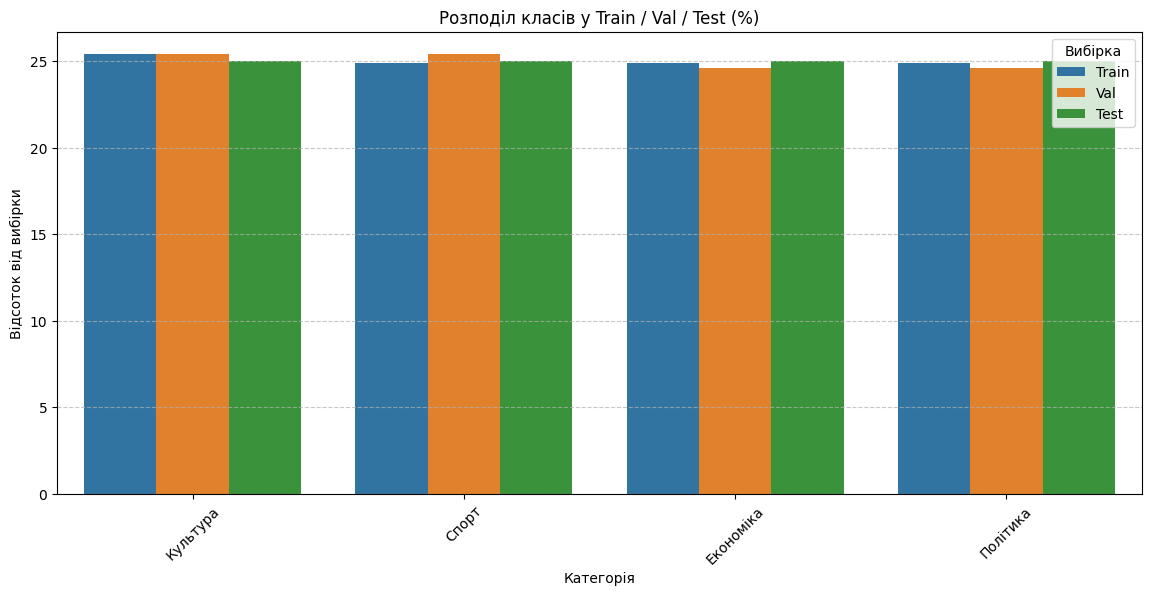

Кількість записів по класах:
Split          Test  Train  Val
Category_Name                  
Економіка        32    144   30
Культура         32    147   31
Політика         32    144   30
Спорт            32    144   31
------------------------------
Метрики моделі на Test set:
Accuracy: 0.9688
Macro-F1: 0.9690
Weighted-F1: 0.9690
------------------------------
Дисбаланс класів відсутній


In [11]:
class_names = {0: "Культура", 1: "Спорт", 2: "Економіка", 3: "Політика"}
metrics = analyze_splits_and_evaluate(y_train, y_val, y_test, y_pred_svc, class_names=class_names)

In [12]:
import pandas as pd
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

def run_linear_svc_comparison(X_train, X_test, y_train, y_test):

    ukr_stopwords = [
        "про", "що", "та", "для", "це", "як", "але", "або", "він", "ми",
        "щоб", "році", "року", "бути", "стати", "щодо", "його", "які",
        "на", "2025", "сказав", "який", "від", "також", "лютого", "про це",
        "місце", "серед", "те", "2026", "зокрема", "пам", "рік",
    ]

    feature_extractor = FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            max_features=20000,
            min_df=3,
            stop_words=ukr_stopwords
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=15000,
            min_df=5
        ))
    ])

    pipeline_balanced = Pipeline([
        ("features", feature_extractor),
        ("clf", LinearSVC(C=1.0, class_weight="balanced", max_iter=2000, random_state=42))
    ])

    pipeline_balanced.fit(X_train, y_train)
    y_pred_balanced = pipeline_balanced.predict(X_test)

    acc = accuracy_score(y_test, y_pred_balanced)
    f1 = f1_score(y_test, y_pred_balanced, average="macro")
    print("Accuracy:", acc)
    print("Macro F1:", f1)
    print("Classification report:\n", classification_report(y_test, y_pred_balanced))
    print("\n")

    return pipeline_balanced, y_pred_balanced, acc, f1


In [13]:
_, _, acc_svc_char_b, f1_svc_char_b = run_linear_svc_comparison(X_train, X_test, y_train, y_test)

Accuracy: 0.984375
Macro F1: 0.9843730921855922
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       1.00      1.00      1.00        32
           2       0.97      1.00      0.98        32
           3       0.97      0.97      0.97        32

    accuracy                           0.98       128
   macro avg       0.98      0.98      0.98       128
weighted avg       0.98      0.98      0.98       128





In [14]:
result_table = pd.DataFrame({
  "Model": ["LogRegbaseline", "LinearSVC", "LinearSVC", "LinearSVC"],
  "Features": ["word(1,2)", "word(1,2)", "word + char", "word + char"],
  "class_weight": ["no", "no", "no", "balanced"],
  "Accuracy": [acc_lr, acc_svc, acc_svc_char, acc_svc_char_b],
  "Macro-F1": [f1_lr, f1_svc, f1_svc_char, f1_svc_char_b]
})

result_table.head()

,Model,Features,class_weight,Accuracy,Macro-F1
0,LogRegbaseline,"word(1,2)",no,0.960938,0.961287
1,LinearSVC,"word(1,2)",no,0.968750,0.968987
2,LinearSVC,word + char,no,0.984375,0.984373
3,LinearSVC,word + char,balanced,0.984375,0.984373


# Висновок
Оскільки у навчальній, валідаційній та тестовій вибірках кількість прикладів для кожного класу є приблизно однаковою, дисбаланс класів відсутній. У зв’язку з цим використання параметра class_weight=None та class_weight="balanced" не призводить до відмінностей у якості моделі: значення метрик accuracy та macro-F1 залишаються однаковими, а результати classification_report — ідентичними.

# Section 8. PR-curve / threshold section



In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix

def evaluate_thresholds(y_true, y_scores, class_id, strategy="balance", class_names=None):
    y_binary = (y_true == class_id).astype(int)
    scores = y_scores[:, class_id]

    precision, recall, thresholds = precision_recall_curve(y_binary, scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

    if strategy == "balance":
        idx = np.argmax(f1_scores)
        reason = "Максимальний F1 (Баланс)"
    elif strategy == "precision-first":
        mask = precision >= 0.90
        if any(mask):
            idx = np.where(mask)[0][0]
            reason = "Precision >= 90% (Мінімум помилкових спрацювань)"
        else:
            idx = np.argmax(precision)
            reason = "Максимально можливий Precision"
    elif strategy == "recall-first":
        mask = recall >= 0.90
        if any(mask):
            idx = np.where(mask)[0][-1]
            reason = "Recall >= 90% (Мінімум пропущених новин)"
        else:
            idx = np.argmax(recall)
            reason = "Максимально можливий Recall"

    final_idx = min(idx, len(thresholds) - 1)
    chosen_threshold = thresholds[final_idx]

    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precision[:-1], label='Precision', color='blue', linestyle='--')
    plt.plot(thresholds, recall[:-1], label='Recall', color='green', linestyle='-')
    plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='red', lw=2)

    plt.axvline(x=chosen_threshold, color='black', linestyle=':', label=f'Обраний поріг: {chosen_threshold:.2f}')

    class_name = class_names[class_id] if class_names else f"ID {class_id}"
    plt.title(f"Підбір порогу для класу '{class_name}'\nСтратегія: {strategy} ({reason})")
    plt.xlabel("Поріг (Decision Score)")
    plt.ylabel("Метрика")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"--- Результати для '{class_name}' ({strategy}) ---")
    print(f"Поріг: {chosen_threshold:.4f}")
    print(f"Precision: {precision[final_idx]:.4f}")
    print(f"Recall: {recall[final_idx]:.4f}")
    print(f"F1 Score: {f1_scores[final_idx]:.4f}")

    return chosen_threshold

def apply_custom_thresholds(y_scores, threshold_dict):
    y_pred_custom = np.argmax(y_scores, axis=1)

    for class_id, threshold in threshold_dict.items():
        mask = y_scores[:, class_id] >= threshold
        y_pred_custom[mask] = class_id

    return y_pred_custom


=== Підбір порогу на ВАЛІДАЦІЙНИХ даних ===


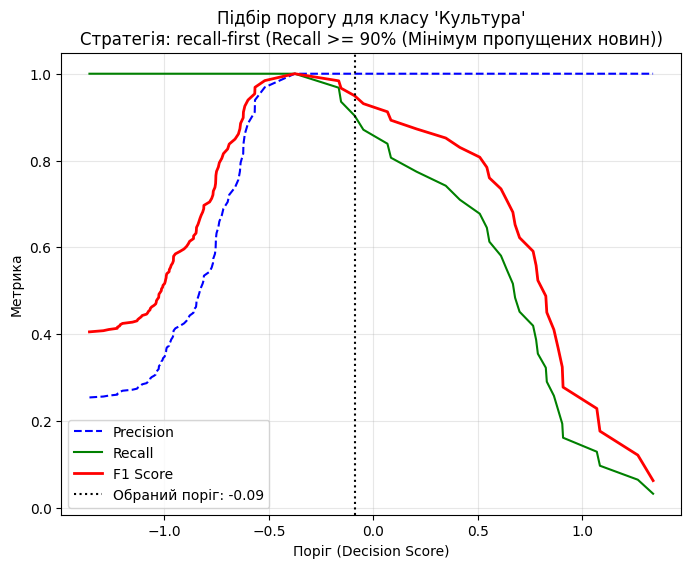

--- Результати для 'Культура' (recall-first) ---
Поріг: -0.0890
Precision: 1.0000
Recall: 0.9032
F1 Score: 0.9492


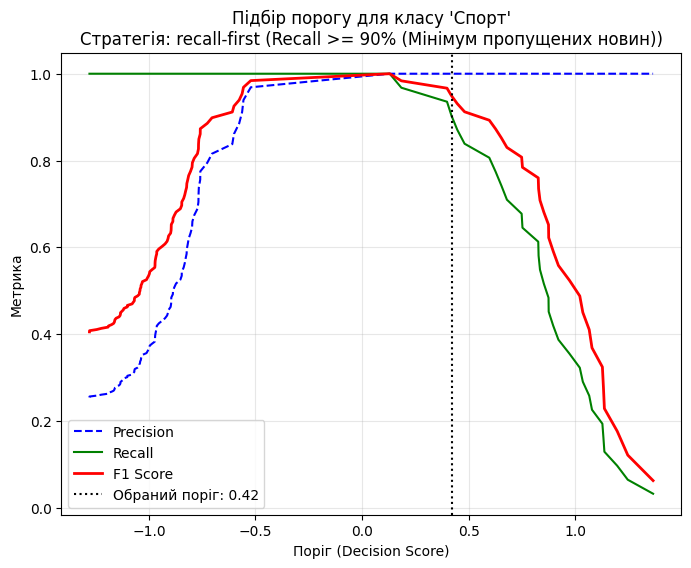

--- Результати для 'Спорт' (recall-first) ---
Поріг: 0.4193
Precision: 1.0000
Recall: 0.9032
F1 Score: 0.9492


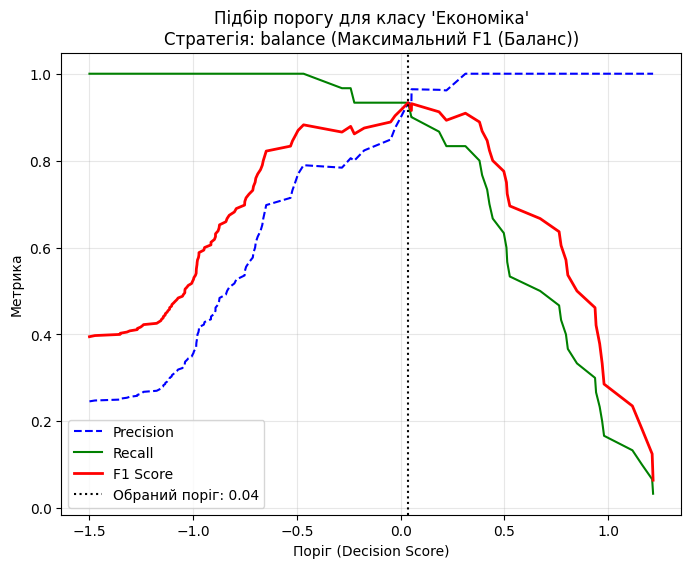

--- Результати для 'Економіка' (balance) ---
Поріг: 0.0361
Precision: 0.9333
Recall: 0.9333
F1 Score: 0.9333


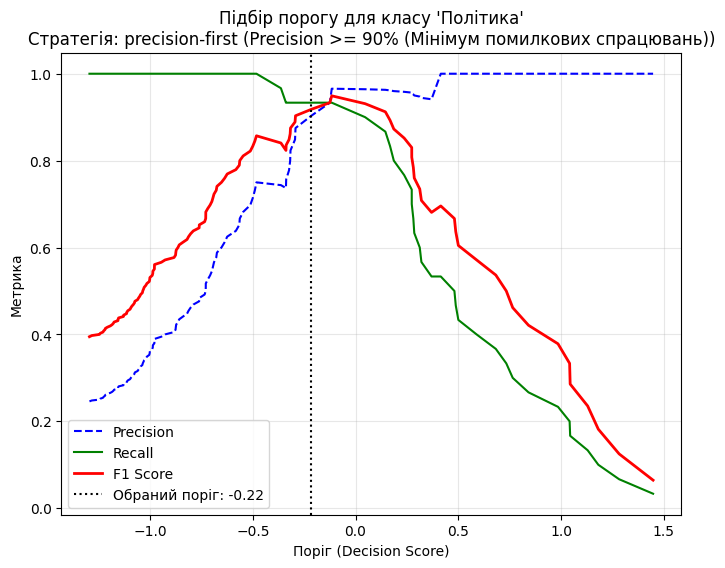

--- Результати для 'Політика' (precision-first) ---
Поріг: -0.2153
Precision: 0.9032
Recall: 0.9333
F1 Score: 0.9180

=== Порівняння результатів на ТЕСТОВІЙ вибірці ===

Стандартний поріг
              precision    recall  f1-score   support

    Культура       1.00      0.97      0.98        32
       Спорт       1.00      1.00      1.00        32
   Економіка       0.97      1.00      0.98        32
    Політика       0.97      0.97      0.97        32

    accuracy                           0.98       128
   macro avg       0.98      0.98      0.98       128
weighted avg       0.98      0.98      0.98       128


Кастомний поріг для Політика: -0.2153
              precision    recall  f1-score   support

    Культура       1.00      0.94      0.97        32
       Спорт       1.00      1.00      1.00        32
   Економіка       1.00      0.97      0.98        32
    Політика       0.91      1.00      0.96        32

    accuracy                           0.98       128
   macro avg

In [16]:
import numpy as np
from sklearn.metrics import classification_report

scores_val = pipeline_svc_char.decision_function(X_val)

print("=== Підбір порогу на ВАЛІДАЦІЙНИХ даних ===")
t_cult = evaluate_thresholds(y_val, scores_val, class_id=0, strategy="recall-first", class_names=class_names)
t_sp = evaluate_thresholds(y_val, scores_val, class_id=1, strategy="recall-first", class_names=class_names)
t_econ = evaluate_thresholds(y_val, scores_val, class_id=2, strategy="balance", class_names=class_names)
t_pol = evaluate_thresholds(y_val, scores_val, class_id=3, strategy="precision-first", class_names=class_names)

scores_test = pipeline_svc_char.decision_function(X_test)
custom_thresholds = {3: t_pol}

y_pred_standard = pipeline_svc_char.predict(X_test)
y_pred_custom = apply_custom_thresholds(scores_test, custom_thresholds)

print("\n=== Порівняння результатів на ТЕСТОВІЙ вибірці ===")
print("\nСтандартний поріг")
print(classification_report(y_test, y_pred_standard, target_names=list(class_names.values())))

print(f"\nКастомний поріг для {class_names[3]}: {t_pol:.4f}")
print(classification_report(y_test, y_pred_custom, target_names=list(class_names.values())))


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, precision_score, classification_report, recall_score
from sklearn.preprocessing import label_binarize

def plot_pr_curve_with_thresholds(y_test, y_score, class_id=0, thresholds_to_show=[0.0, 0.5], class_names=None):
    y_binary = (y_test == class_id).astype(int)
    scores = y_score[:, class_id]

    precision, recall, thresholds = precision_recall_curve(y_binary, scores)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, lw=2, label="PR curve")

    for t in thresholds_to_show:
        idx = np.argmin(np.abs(thresholds - t))
        plt.scatter(recall[idx], precision[idx], s=80, label=f"t={thresholds[idx]:.2f}")

    class_name = class_names[class_id] if class_names else f"Клас {class_id}"

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR-крива для класу '{class_name}'")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"--- Порівняння порогів для '{class_name}' ---")
    for t in thresholds_to_show:
        y_pred = (scores >= t).astype(int)
        p = precision_score(y_binary, y_pred)
        r = recall_score(y_binary, y_pred)
        f1 = f1_score(y_binary, y_pred)

        print(f"t = {t:.2f} → Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")


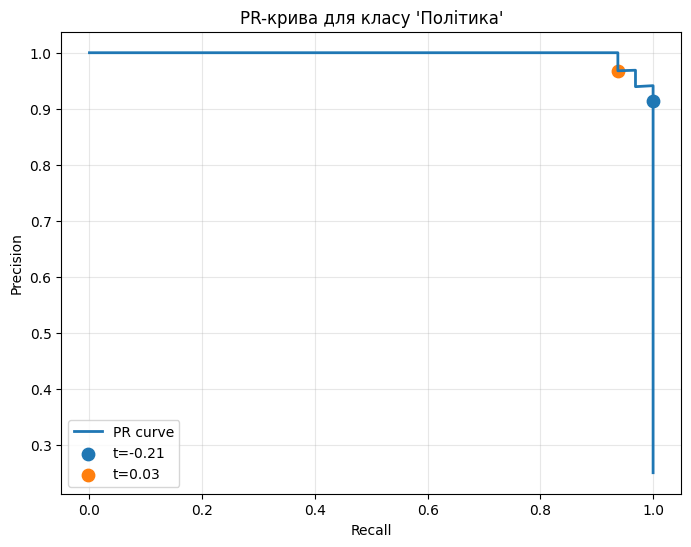

--- Порівняння порогів для 'Політика' ---
t = -0.22 → Precision=0.914, Recall=1.000, F1=0.955
t = 0.00 → Precision=0.968, Recall=0.938, F1=0.952


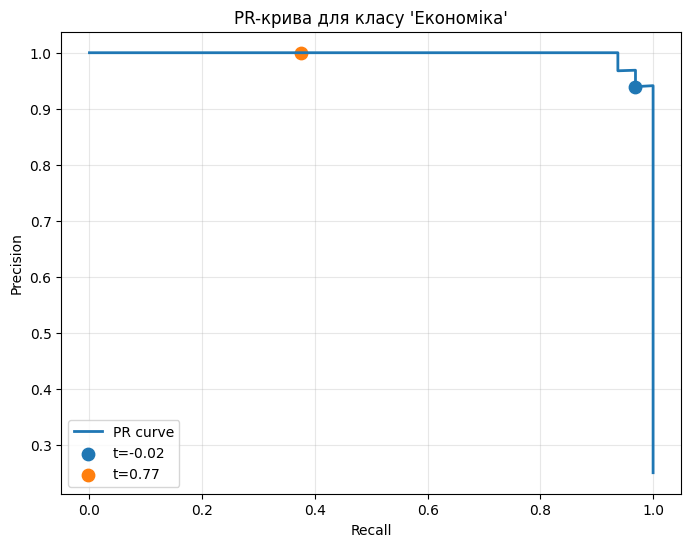

--- Порівняння порогів для 'Економіка' ---
t = 0.04 → Precision=0.969, Recall=0.969, F1=0.969
t = 0.80 → Precision=1.000, Recall=0.344, F1=0.512


In [18]:
y_score = pipeline_svc_char.decision_function(X_test)

plot_pr_curve_with_thresholds(
    y_test,
    y_score,
    class_id=3,
    thresholds_to_show=[-0.2153, 0.0],
    class_names=class_names
)

plot_pr_curve_with_thresholds(
    y_test,
    y_score,
    class_id=2,
    thresholds_to_show=[0.0361, 0.8],
    class_names=class_names
)

Для класів "політика" та "економіка" було побудовано PR-криві в постановці one-vs-rest. Для класу "політика" порівняно стандартний поріг (t = 0) та кастомний поріг (t = -0.22). Зі зростанням порогу спостерігається підвищення precision та зниження recall. Обраний кастомний поріг дозволяє зменшити кількість хибних спрацювань (FP), що є критично важливим для цього класу.

Для класу "економіка" порівняно підвищений поріг (t = 0.8) та кастомний поріг (t = 0.04). Обраний поріг відповідає максимуму F1-міри, що забезпечує баланс між precision та recall, оскільки для даного класу важливими є як хибні спрацювання (FP), так і пропущені приклади (FN).

# Висновок
Для підбору порогів класифікації було використано значення decision_function моделі SVC. На їх основі побудовано криві Precision-Recall, що дозволяють проаналізувати залежність між точністю (precision) та повнотою (recall) при зміні порогу.

Стандартний підхід передбачає вибір класу з максимальним значенням decision score. Додатково було реалізовано підбір кастомних порогів на валідаційній вибірці для кожного класу, що дозволяє гнучко налаштувати поведінку моделі відповідно до специфіки задачі.

Для класу "політика" застосовано стратегію precision-first, оскільки важливо мінімізувати хибні спрацювання (FP). Для класів "спорт" і "культура" використано підхід recall-first з метою зменшення кількості пропущених релевантних новин (FN). Для класу "економіка" обрано баланс між precision і recall, що відповідає максимізації F1-міри.

Основну увагу приділено класу "політика" як найбільш критичному. Для нього було обрано поріг, що забезпечує значення precision≥0.9 навіть за рахунок зниження recall, оскільки помилкове віднесення новини до політичної категорії є небажаним.

Аналіз PR-кривих показує, що зі зменшенням порогу зростає recall, але знижується precision, і навпаки. Обрані пороги дозволяють адаптувати модель до вимог задачі та зменшити найбільш критичні типи помилок.

# Section 9. Confusion matrix comparison


In [19]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Прогнозований клас")
    plt.ylabel("Справжній клас")
    plt.title(title)
    plt.tight_layout()
    plt.show()

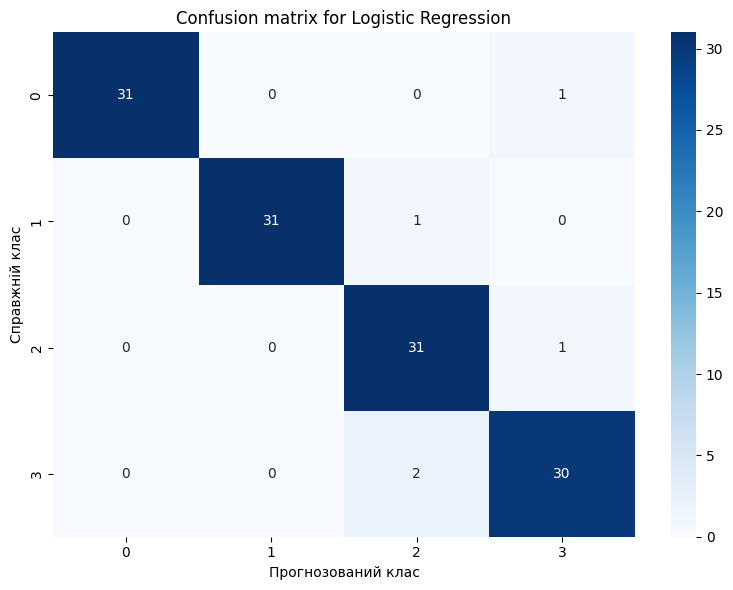

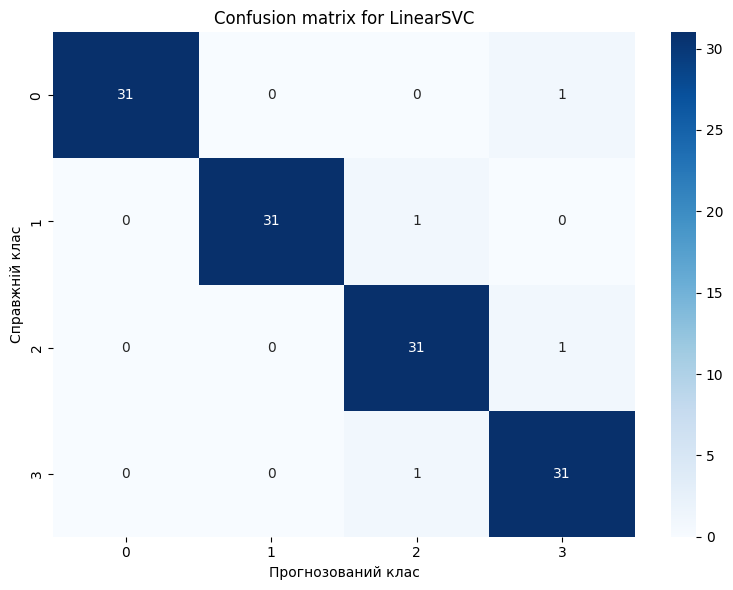

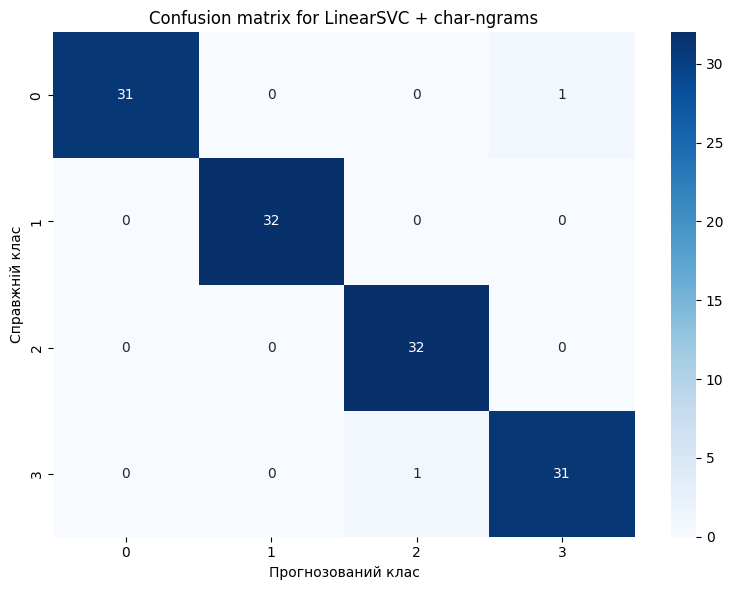

In [20]:
plot_confusion_matrix(y_test, y_pred_lr, "Confusion matrix for Logistic Regression")
plot_confusion_matrix(y_test, y_pred_svc, "Confusion matrix for LinearSVC")
plot_confusion_matrix(y_test, y_pred_svc_char, "Confusion matrix for LinearSVC + char-ngrams")

In [21]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

report_dict = classification_report(y_test, y_pred_svc_char, output_dict=True)
report_df = pd.DataFrame(report_dict).T

support_df = report_df.iloc[:-3][["support"]]
print(support_df)
print("\n")

cm = confusion_matrix(y_test, y_pred_svc_char)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = np.dstack(np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1], cm_no_diag.shape))[0]
top_pairs = pairs[:5]

for i, j in top_pairs:
  if i == j:
    continue
  else:
    print(f"{class_names[i]} → {class_names[j]}: {cm[i, j]}")

   support
0     32.0
1     32.0
2     32.0
3     32.0


Політика → Економіка: 1
Культура → Політика: 1
Політика → Спорт: 0
Економіка → Політика: 0


# Висновок
Аналіз confusion matrix показав, що найчастіше плутаються класи "економіка" та "політика", що зумовлено подібністю тематичного контексту цих новин. Використання char n-grams дозволило суттєво зменшити кількість таких помилок: з 4 до 2, що свідчить про покращення здатності моделі розрізняти близькі за змістом тексти.

# Section 10. Error analysis

In [22]:
_, _, _, _, errors_df_svc = run_linear_svc(
    X_train, pd.concat([X_test, X_val]),
    y_train, pd.concat([y_test, y_val])
)

errors_df_svc.head(10)

Accuracy: 0.96
Macro F1: 0.9601221742443485
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        63
           1       1.00      0.98      0.99        63
           2       0.91      0.95      0.93        62
           3       0.94      0.94      0.94        62

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250





,text_id,text,gold_label,predicted_label,comment
0,15,"LRT. Моргенштерна було включено до списку ""не...",0,3,
1,267,"на сайті УЄФА. Зазначається, що вперше за всю ...",1,2,
2,474,заявила єврокомісарка з питань розширення Март...,2,3,
3,781,"""Попри складну внутрішньополітичну ситуацію у ...",3,2,
4,144,"йдеться на сайті КОВА. ""У ЗМІ шириться інформа...",0,2,
5,594,"""Палата представників США ухвалила резолюцію п...",2,3,
6,423,"Відповідне рішення підтримали 458 депутатів, 1...",2,3,
7,644,Відповідний указ №100/2026 оприлюднено на сайт...,3,2,
8,726,глава української дипломатії написав у соцмере...,3,2,
9,742,міністр внутрішніх справ Ігор Клименко у Телег...,3,2,


In [23]:
errors_df_svc.rename(columns={'index': 'text_id'}, inplace=True)

errors_df_svc.loc[errors_df_svc["text_id"] == 144, "comment"] = "Економічний контекст домінує над культурним, що зумовлює помилкову класифікацію."
errors_df_svc.loc[errors_df_svc["text_id"] == 726, "comment"] = "Новина містить економічну тематику (транзит нафти), проте домінують політичні причини нестабільності, через що модель віддає перевагу політичному класу"
errors_df_svc.loc[errors_df_svc["text_id"] == 474, "comment"] = "У тексті присутні економічні показники, проте вони використовуються в межах опису політичних рішень. Модель орієнтується на політичний контекст та ігнорує фінансові ознаки."
errors_df_svc.loc[errors_df_svc["text_id"] == 781, "comment"] = "Новина акцентує увагу на обсягах гуманітарної та фінансової допомоги, тоді як інформація про країну-донор представлена менш виразно. Це зумовлює зміщення класифікації в бік економічної тематики."
errors_df_svc.loc[errors_df_svc["text_id"] == 15 , "comment"] = "У новині описується заборона пісень та концертів виконавця з міркувань державної безпеки. Політичний контекст домінує над культурним, що зумовлює помилкову класифікацію."
errors_df_svc.loc[errors_df_svc["text_id"] == 267, "comment"] = "Новина містить інформацію про доходи УЄФА та значну кількість фінансових показників. Через домінування економічної лексики модель класифікує текст як економічний, незважаючи на його спортивний контекст."
errors_df_svc.loc[errors_df_svc["text_id"] == 644, "comment"] = "Текст є занадто коротким і не містить достатньої кількості інформативних ознак для коректної класифікації."
errors_df_svc.loc[errors_df_svc["text_id"] == 742, "comment"] = "У новині переважають політичні маркери, які затьмарюють основну тему транспортного сполучення (пасажирського і вантажного), що призводить до помилки класифікації."
errors_df_svc.loc[errors_df_svc["text_id"] == 594, "comment"] = "Новина містить численні політичні маркери (згадки про Конгрес, Дональда Трампа, наркотрафік), які переважають економічну складову (тарифи), що впливає на рішення моделі."
errors_df_svc.loc[errors_df_svc["text_id"] == 423, "comment"] = "У тексті домінують політичні маркери (ЄС, Україна, Комісія), які мають більшу вагу порівняно з економічними ознаками, що зумовлює відповідну класифікацію."

errors_df_svc.to_json("error_cases_lab7.jsonl", orient="records", lines=True, force_ascii=False)

# Категоризація помилок
1. Overlap класів (змішана тематика)
2. Домінування сильних маркерів (feature bias)
3. Короткий або недостатньо інформативний текст

Найчастіше зустрічаються помилки типу overlap класів та домінування сильних маркерів, що свідчить про складність текстів із змішаною тематикою та залежність моделі від окремих вагомих слів.

# Section 11. Generate docs/audit_summary_lab7.md

In [24]:
report = f"""# Audit Summary — Lab 7 (Linear SVM + char-ngrams + imbalance)

## Задача

**Тип задачі:** А — класифікація текстів (тема/тональність/спам/urgency)


## Baseline (ЛР6): TF-IDF + Logistic Regression

У якості базової моделі використано TF-IDF (word n-grams) у поєднанні з Logistic Regression.
Accuracy: {acc_lr}
Macro-F1: {f1_lr}


## SVM-моделі

Було досліджено такі варіанти:
1. SVM word baseline
TF-IDF (word n-grams (1,2)) + LinearSVC
2. SVM + char-ngrams
TF-IDF (word (1,2) + char n-grams) + LinearSVC
* `analyzer="char_wb"`
* `ngram_range=(3,5)`


## Найкращий результат

Найкращі результати продемонструвала модель з використанням char n-grams:
Accuracy: {acc_svc_char}
Macro-F1: {f1_svc_char}


## Вплив char-ngrams

Використання символьних n-грам дозволило суттєво покращити якість класифікації, зокрема зменшити кількість помилок між тематично близькими класами ("економіка" та "політика") приблизно вдвічі. Це свідчить про те, що char n-grams допомагають моделі краще враховувати морфологічні та часткові збіги слів.


## Вплив class_weight

Оскільки у навчальній, валідаційній та тестовій вибірках кількість прикладів для кожного класу є приблизно однаковою, дисбаланс класів відсутній. У зв’язку з цим використання параметра class_weight=None та class_weight="balanced" не призводить до відмінностей у якості моделі: значення accuracy та macro-F1 залишилися незмінними, а результати classification_report — ідентичними.


## Підбір порогів (PR-логіка)

Для аналізу було використано значення decision_function моделі SVM та побудовано PR-криві в постановці one-vs-rest.
Основну увагу приділено класу "політика" як найбільш критичному:
* застосовано стратегію precision-first
* обрано поріг, що забезпечує precision ≥ 0.9
* це дозволяє мінімізувати хибні спрацювання (FP), навіть за рахунок зниження recall
Такий підхід є виправданим, оскільки помилкове віднесення новини до політичної категорії є небажаним.


## Найчастіші типи помилок

1. Overlap класів (змішана тематика)
Текст містить ознаки одразу кількох класів, і модель обирає той, де ознаки мають більшу вагу.
2. Домінування сильних маркерів (feature bias)
Окремі слова ('грн', 'млн', політичні імена) мають занадто велику вагу і “перетягують” класифікацію.
3. Короткий або недостатньо інформативний текст
Недостатня кількість ознак призводить до нестабільних або випадкових передбачень.
"""

with open("audit_summary_lab7.md", "w", encoding="utf-8") as f:
    f.write(report)